# Confidence Head Checkpoint Training

This notebook trains the confidence head after the folding checkpoint exists. It loads the complete folding model, freezes the PLM, folding core, and structure denoiser, then trains `ConfidenceHead` to estimate the accuracy of structures produced by the sampler. The final checkpoint keeps the complete model so it can be loaded directly by `inference.ipynb`.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from model.protein_folding import (
    ProteinDataLoaderLite,
    ProteinFolding,
    ProteinFoldingConfig,
    confidence_supervision_loss,
    folding_model_inputs,
)


## Devices & Paths

We keep the same data and checkpoint layout as the other training notebooks. This stage starts from `protein_folding_folding.pt` and writes a new complete checkpoint with the trained confidence head.


In [2]:
SEED = 1337

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)
print(f'using {device}')

data_root = Path('~/data/protein_folding').expanduser()
shard_path = data_root / 'tokenized'
folding_checkpoint_path = data_root / 'checkpoint' / 'protein_folding_folding.pt'
confidence_checkpoint_path = data_root / 'checkpoint' / 'protein_folding_confidence.pt'
confidence_checkpoint_path.parent.mkdir(parents=True, exist_ok=True)


using cpu


## Setup

The confidence head learns from structures generated by the frozen sampler. We use the same structural cache as folding training because it provides both the model inputs and the known coordinates needed to calculate the confidence targets. We load the folding configuration first so the data loader and confidence rollout use the settings saved with the model.


In [3]:
folding_checkpoint = torch.load(folding_checkpoint_path, map_location=device, weights_only=False)
folding_cfg = ProteinFoldingConfig(**folding_checkpoint['config'])

batch_size = 2
epochs = 10
lr = 1e-4
weight_decay = 0.01
confidence_rollout_steps = folding_cfg.confidence_rollout_steps


In [4]:
def count_split_examples(root, split):
    total = 0
    for path in sorted((root / split).glob('*.npz')):
        with np.load(path, allow_pickle=False) as shard:
            total += int(shard['input_ids'].shape[0])
    return total


train_examples = count_split_examples(shard_path, 'train')
val_examples = count_split_examples(shard_path, 'val')
steps_per_epoch = (train_examples + batch_size - 1) // batch_size
val_steps = (val_examples + batch_size - 1) // batch_size
max_steps = epochs * steps_per_epoch

print(f'train examples: {train_examples:,}')
print(f'val examples: {val_examples:,}')
print(f'steps per epoch: {steps_per_epoch:,}')
print(f'total steps: {max_steps:,}')


train examples: 113
val examples: 14
steps per epoch: 57
total steps: 570


In [5]:
train_loader = ProteinDataLoaderLite(
    shard_path,
    batch_size,
    block_size=folding_cfg.block_size,
    split='train',
    seed=SEED,
)
val_loader = ProteinDataLoaderLite(
    shard_path,
    batch_size,
    block_size=folding_cfg.block_size,
    split='val',
    seed=SEED + 1,
)


## Model

The folding checkpoint already contains the PLM and every folding module, so we reconstruct the complete model from its saved configuration and load the full state dictionary. We then freeze everything and turn gradients back on only for the confidence head. The frozen model stays in evaluation mode while the confidence head switches to training mode for its own forward pass.


In [6]:
(
    folding_checkpoint['stage'],
    folding_checkpoint['step'],
    folding_cfg.block_size,
    confidence_rollout_steps,
)


('folding_training', 1425, 64, 4)

In [7]:
model = ProteinFolding(folding_cfg).to(device)
model.load_state_dict(folding_checkpoint['model'])

for parameter in model.parameters():
    parameter.requires_grad = False
for parameter in model.confidence_head.parameters():
    parameter.requires_grad = True

model.eval()
model.confidence_head.train()

optimizer = torch.optim.AdamW(
    model.confidence_head.parameters(),
    lr=lr,
    weight_decay=weight_decay,
)

parameter_count = sum(parameter.numel() for parameter in model.parameters())
trainable_count = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
trainable_names = [name for name, parameter in model.named_parameters() if parameter.requires_grad]
assert trainable_names and all(name.startswith('confidence_head.') for name in trainable_names)

print(f'parameters: {parameter_count:,}')
print(f'trainable:  {trainable_count:,}')


parameters: 3,692,146
trainable:  442,599


## Confidence Training Example

The confidence head should judge coordinates produced by the model, not the known target structure. For each training batch, we run a short frozen diffusion rollout and ask the sampler to return the detached folding features used by `ConfidenceHead`. We then run the confidence head again with gradients and compare its predictions against confidence targets calculated from the sampled and known coordinates.

Before training, we also keep one fixed validation example and run the full inference schedule. We will use the same example, coordinates, and seed after training so we can compare the confidence head before and after its weights change.


In [8]:
example_batch = val_loader.next_batch(device)
val_loader.reset()

model.eval()
with torch.no_grad():
    example_sample = model.sample(
        **folding_model_inputs(example_batch),
        num_steps=folding_cfg.sampling_steps,
        seed=SEED + 20_000,
        return_confidence_inputs=True,
    )
    example_confidence_inputs = example_sample['confidence_inputs']
    example_confidence_output = model.confidence_head(
        example_confidence_inputs['x_inputs'],
        example_confidence_inputs['pair'],
        example_confidence_inputs['atom_coords'],
        example_confidence_inputs['distogram_atom_idx'],
        example_confidence_inputs['residue_mask'],
        example_confidence_inputs['atom_to_token'],
        example_confidence_inputs['atom_mask'],
        example_confidence_inputs['asym_id'],
        example_confidence_inputs['mol_type'],
        relative_position_encoding=example_confidence_inputs['relative_position_encoding'],
        token_bond_features=example_confidence_inputs['token_bond_features'],
    )
    example_loss, example_targets = confidence_supervision_loss(
        example_confidence_output,
        example_confidence_inputs['atom_coords'],
        example_batch['atom_coords'],
        example_confidence_inputs['target_atom_mask'],
        example_confidence_inputs['reference_atom_mask'],
        example_confidence_inputs['residue_mask'],
        example_confidence_inputs['atom_to_token'],
        example_confidence_inputs['distogram_atom_idx'],
    )

example_length = int(example_confidence_inputs['residue_mask'][0].sum().item())
baseline_predicted_confidence = example_confidence_output['predicted_plddt'][0, :example_length].cpu()
observed_confidence = 100.0 * example_targets['residue_lddt'][0, :example_length].cpu()

float(example_loss.item()), example_confidence_inputs['atom_coords'].shape, example_confidence_inputs['pair'].shape


(4.631436824798584, torch.Size([2, 2368, 3]), torch.Size([2, 64, 64, 64]))

## Train

Each step has two separate passes. First, the frozen sampler generates coordinates and detached folding features without building a gradient graph. Second, the confidence head uses those features to predict residue lDDT, atom pLDDT, PAE, PDE, and resolved atoms. Only their combined confidence loss is minimized, so no diffusion, pair-distance, or distogram loss enters this stage.


In [9]:
loss_names = ['scalar', 'plddt', 'pae', 'pde', 'resolved']
loss_history = []
component_history = []
val_history = []
train_loss_total = 0.0
train_component_total = {
    'scalar': 0.0,
    'plddt': 0.0,
    'pae': 0.0,
    'pde': 0.0,
    'resolved': 0.0,
}


In [10]:
for step in range(1, max_steps + 1):
    batch = train_loader.next_batch(device)

    model.eval()
    with torch.no_grad():
        sample = model.sample(
            **folding_model_inputs(batch),
            num_steps=confidence_rollout_steps,
            seed=SEED + step,
            return_confidence_inputs=True,
        )
    confidence_inputs = sample['confidence_inputs']

    model.confidence_head.train()
    confidence_output = model.confidence_head(
        confidence_inputs['x_inputs'],
        confidence_inputs['pair'],
        confidence_inputs['atom_coords'],
        confidence_inputs['distogram_atom_idx'],
        confidence_inputs['residue_mask'],
        confidence_inputs['atom_to_token'],
        confidence_inputs['atom_mask'],
        confidence_inputs['asym_id'],
        confidence_inputs['mol_type'],
        relative_position_encoding=confidence_inputs['relative_position_encoding'],
        token_bond_features=confidence_inputs['token_bond_features'],
    )
    loss, loss_details = confidence_supervision_loss(
        confidence_output,
        confidence_inputs['atom_coords'],
        batch['atom_coords'],
        confidence_inputs['target_atom_mask'],
        confidence_inputs['reference_atom_mask'],
        confidence_inputs['residue_mask'],
        confidence_inputs['atom_to_token'],
        confidence_inputs['distogram_atom_idx'],
    )

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.confidence_head.parameters(), 1.0)
    optimizer.step()

    loss_value = float(loss.item())
    loss_history.append(loss_value)
    train_loss_total += loss_value
    for name in loss_names:
        train_component_total[name] += float(loss_details[name].item())

    if step % steps_per_epoch == 0:
        epoch = step // steps_per_epoch
        model.eval()
        val_loader.reset()
        val_loss_total = 0.0
        val_component_total = {
            'scalar': 0.0,
            'plddt': 0.0,
            'pae': 0.0,
            'pde': 0.0,
            'resolved': 0.0,
        }

        with torch.no_grad():
            for val_step in range(val_steps):
                batch = val_loader.next_batch(device)
                sample = model.sample(
                    **folding_model_inputs(batch),
                    num_steps=confidence_rollout_steps,
                    seed=SEED + 10_000 + val_step,
                    return_confidence_inputs=True,
                )
                confidence_inputs = sample['confidence_inputs']
                confidence_output = model.confidence_head(
                    confidence_inputs['x_inputs'],
                    confidence_inputs['pair'],
                    confidence_inputs['atom_coords'],
                    confidence_inputs['distogram_atom_idx'],
                    confidence_inputs['residue_mask'],
                    confidence_inputs['atom_to_token'],
                    confidence_inputs['atom_mask'],
                    confidence_inputs['asym_id'],
                    confidence_inputs['mol_type'],
                    relative_position_encoding=confidence_inputs['relative_position_encoding'],
                    token_bond_features=confidence_inputs['token_bond_features'],
                )
                val_loss, val_details = confidence_supervision_loss(
                    confidence_output,
                    confidence_inputs['atom_coords'],
                    batch['atom_coords'],
                    confidence_inputs['target_atom_mask'],
                    confidence_inputs['reference_atom_mask'],
                    confidence_inputs['residue_mask'],
                    confidence_inputs['atom_to_token'],
                    confidence_inputs['distogram_atom_idx'],
                )
                val_loss_total += float(val_loss.item())
                for name in loss_names:
                    val_component_total[name] += float(val_details[name].item())

        train_loss = train_loss_total / steps_per_epoch
        val_loss = val_loss_total / val_steps
        train_components = {
            name: value / steps_per_epoch
            for name, value in train_component_total.items()
        }
        val_components = {
            name: value / val_steps
            for name, value in val_component_total.items()
        }
        val_history.append((step, val_loss))
        component_history.append((step, train_components, val_components))

        print(
            f'epoch {epoch:2d} | train loss {train_loss:.4f} | val loss {val_loss:.4f} | '
            f'scalar {train_components["scalar"]:.4f} | pLDDT {train_components["plddt"]:.4f} | '
            f'PAE {train_components["pae"]:.4f} | PDE {train_components["pde"]:.4f} | '
            f'resolved {train_components["resolved"]:.4f}'
        )

        train_loss_total = 0.0
        train_component_total = {
            'scalar': 0.0,
            'plddt': 0.0,
            'pae': 0.0,
            'pde': 0.0,
            'resolved': 0.0,
        }
        model.confidence_head.train()

torch.save(
    {
        'stage': 'confidence_training',
        'model': model.state_dict(),
        'config': folding_cfg.__dict__,
        'step': max_steps,
        'loss_history': loss_history,
        'val_history': val_history,
        'component_history': component_history,
        'folding_checkpoint': str(folding_checkpoint_path),
    },
    confidence_checkpoint_path,
)
print(f'saved checkpoint: {confidence_checkpoint_path}')


epoch  1 | train loss 3.3426 | val loss 2.5604 | scalar 0.1042 | pLDDT 4.6332 | PAE 4.0590 | PDE 3.9564 | resolved 0.3050
epoch  2 | train loss 2.3794 | val loss 2.2550 | scalar 0.0085 | pLDDT 3.0889 | PAE 3.1098 | PDE 3.1071 | resolved 0.1775
epoch  3 | train loss 2.1972 | val loss 2.1545 | scalar 0.0044 | pLDDT 2.7506 | PAE 2.9278 | PDE 2.9184 | resolved 0.1746
epoch  4 | train loss 2.1209 | val loss 2.1130 | scalar 0.0038 | pLDDT 2.6291 | PAE 2.8436 | PDE 2.8296 | resolved 0.1663
epoch  5 | train loss 2.0757 | val loss 2.1063 | scalar 0.0033 | pLDDT 2.5725 | PAE 2.7829 | PDE 2.7759 | resolved 0.1583
epoch  6 | train loss 2.0572 | val loss 2.0839 | scalar 0.0032 | pLDDT 2.5612 | PAE 2.7500 | PDE 2.7434 | resolved 0.1611
epoch  7 | train loss 2.0454 | val loss 2.0787 | scalar 0.0031 | pLDDT 2.5466 | PAE 2.7132 | PDE 2.7074 | resolved 0.2018
epoch  8 | train loss 2.0203 | val loss 2.0750 | scalar 0.0028 | pLDDT 2.5194 | PAE 2.7112 | PDE 2.7080 | resolved 0.1316
epoch  9 | train loss 2.

## Loss Curves

The total curve shows whether confidence supervision is improving overall. The component curves separate residue lDDT, atom pLDDT, PAE, PDE, and resolved-atom learning so we can see whether one output is dominating the combined loss.


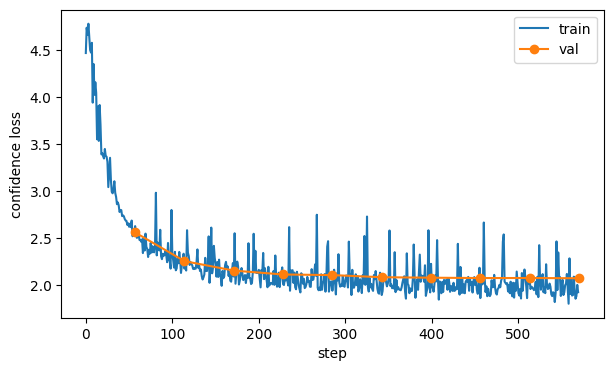

In [11]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history, label='train')
if val_history:
    steps = [item[0] for item in val_history]
    values = [item[1] for item in val_history]
    plt.plot(steps, values, marker='o', label='val')
plt.xlabel('step')
plt.ylabel('confidence loss')
plt.legend()
plt.show()


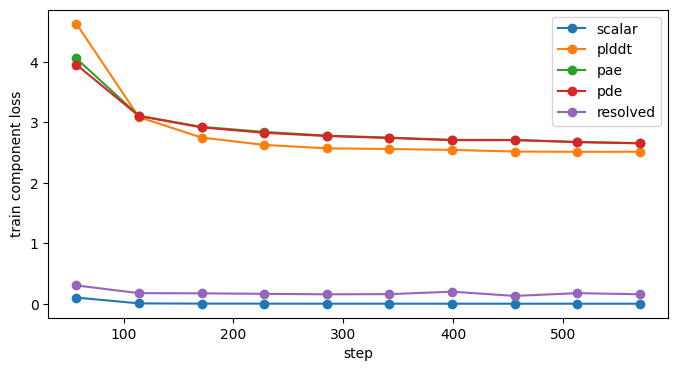

In [12]:
if component_history:
    steps = [item[0] for item in component_history]
    plt.figure(figsize=(8, 4))
    for name in loss_names:
        plt.plot(steps, [item[1][name] for item in component_history], marker='o', label=name)
    plt.xlabel('step')
    plt.ylabel('train component loss')
    plt.legend()
    plt.show()


## Predicted and Observed Confidence

Finally, we run the same fixed validation example again and compare its predicted residue pLDDT with the residue lDDT calculated from the sampled and known structures. The sampler uses the same seed and full diffusion schedule as the baseline, which keeps the sampled coordinates fixed while the trained confidence head makes a new estimate.


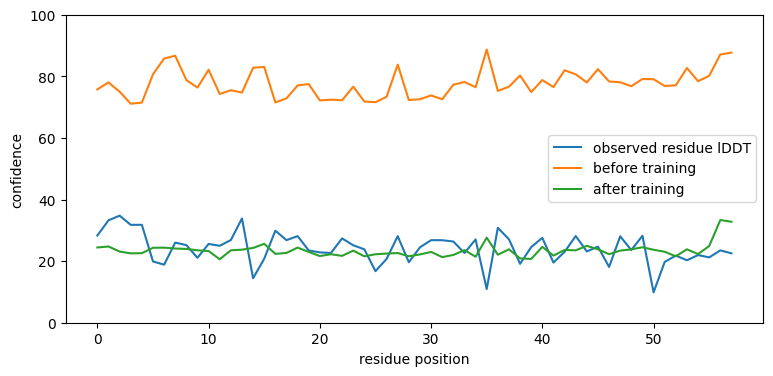

In [13]:
model.eval()
with torch.no_grad():
    trained_example_sample = model.sample(
        **folding_model_inputs(example_batch),
        num_steps=folding_cfg.sampling_steps,
        seed=SEED + 20_000,
        return_confidence_inputs=True,
    )
    trained_confidence_inputs = trained_example_sample['confidence_inputs']
    confidence_output = model.confidence_head(
        trained_confidence_inputs['x_inputs'],
        trained_confidence_inputs['pair'],
        trained_confidence_inputs['atom_coords'],
        trained_confidence_inputs['distogram_atom_idx'],
        trained_confidence_inputs['residue_mask'],
        trained_confidence_inputs['atom_to_token'],
        trained_confidence_inputs['atom_mask'],
        trained_confidence_inputs['asym_id'],
        trained_confidence_inputs['mol_type'],
        relative_position_encoding=trained_confidence_inputs['relative_position_encoding'],
        token_bond_features=trained_confidence_inputs['token_bond_features'],
    )

residue_positions = torch.arange(example_length)
trained_predicted_confidence = confidence_output['predicted_plddt'][0, :example_length].cpu()

plt.figure(figsize=(9, 4))
plt.plot(residue_positions, observed_confidence, label='observed residue lDDT')
plt.plot(residue_positions, baseline_predicted_confidence, label='before training')
plt.plot(residue_positions, trained_predicted_confidence, label='after training')
plt.xlabel('residue position')
plt.ylabel('confidence')
plt.ylim(0, 100)
plt.legend()
plt.show()


## Output Tensors

The trained confidence checkpoint now exposes the same outputs used during inference: residue and atom pLDDT, PAE, PDE, resolved-atom probabilities, and whole-structure TM-style scores.


In [14]:
(
    confidence_output['predicted_plddt'].shape,
    confidence_output['plddt_per_atom'].shape,
    confidence_output['pae_logits'].shape,
    confidence_output['pde_logits'].shape,
    confidence_output['resolved_logits'].shape,
)


(torch.Size([2, 64]),
 torch.Size([2, 2368]),
 torch.Size([2, 64, 64, 32]),
 torch.Size([2, 64, 64, 32]),
 torch.Size([2, 2368, 2]))

In [15]:
(
    confidence_output['complex_plddt'],
    confidence_output['predicted_tm'],
    confidence_output['predicted_iptm'],
)


(tensor([23.4641, 23.8736]),
 tensor([0.3370, 0.3604]),
 tensor([0.3370, 0.3604]))